In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import numba

In [2]:
data_dir = Path("../data")
csv_file = data_dir / "recombinants.csv"
df = pd.read_csv(csv_file)
df.head(2)

,recombinant,sample_id,num_descendant_samples,num_samples,distinct_sample_pango,interval_left,interval_right,num_mutations,Viridian_amplicon_scheme,Artic_primer_version,...,parent_mrca_pango,parent_mrca_scorpio,parent_mrca_time,parent_mrca_date,is_rebar_recombinant,parent_pangonet_distance,net_min_supporting_loci_lft,net_min_supporting_loci_rgt,net_min_supporting_loci_lft_rgt_ge_4,k1000_muts
0,1438470,SRR19695004,1,1,1,519,670,2,COVID-AMPLISEQ-V1,.,...,B.1.1.529,Omicron (Unassigned),1333.857513,2020-10-12,True,3,2,55,False,6
1,1540083,ERR9939974,1,1,1,695,958,1,COVID-ARTIC-V4.1,.,...,B.1.1.529,Omicron (Unassigned),1333.857513,2020-10-12,False,4,1,12,False,9


In [3]:
import tszip
ts_file = data_dir / "sc2ts_viridian_v2.2.trees.tsz"
ts = tszip.decompress(ts_file)

In [4]:
df = df[df.net_min_supporting_loci_lft_rgt_ge_4].reset_index(drop=True)
len(df)

647

In [5]:
# Let's start with the cases where both the parents are sample nodes.
import tskit
parent_left_is_sample = ts.nodes_flags[df.parent_left.iloc[:].to_numpy()] == tskit.NODE_IS_SAMPLE
parent_right_is_sample = ts.nodes_flags[df.parent_right.iloc[:].to_numpy()] == tskit.NODE_IS_SAMPLE
df["parent_left_is_sample"] = parent_left_is_sample
df["parent_right_is_sample"] = parent_right_is_sample
df

,recombinant,sample_id,num_descendant_samples,num_samples,distinct_sample_pango,interval_left,interval_right,num_mutations,Viridian_amplicon_scheme,Artic_primer_version,...,parent_mrca_time,parent_mrca_date,is_rebar_recombinant,parent_pangonet_distance,net_min_supporting_loci_lft,net_min_supporting_loci_rgt,net_min_supporting_loci_lft_rgt_ge_4,k1000_muts,parent_left_is_sample,parent_right_is_sample
0,1872434,ERR12554229,2,1,1,2335,3431,1,COVID-ARTIC-V3,.,...,961.384849,2021-10-19,True,13,4,75,True,5,True,False
1,1358369,ERR9380041,1,1,1,2833,3542,0,COVID-ARTIC-V4.1,4.1alt,...,1333.857513,2020-10-12,True,3,5,46,True,5,False,False
2,1890014,ERR13322922,2,1,1,3432,3565,2,COVID-ARTIC-V5.0-5.3.2_400,.,...,961.384849,2021-10-19,True,10,4,72,True,6,True,False
3,1793239,ERR11148908,5,1,1,3858,3927,3,COVID-ARTIC-V4.1,.,...,961.384849,2021-10-19,True,12,5,38,True,7,True,False
4,857687,ERR7480952,2,2,1,3402,4100,2,COVID-ARTIC-V4.1,4,...,1268.244029,2020-12-16,False,2,5,15,True,7,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
642,1602821,SRR21222419,1,1,1,27439,28681,1,COVID-ARTIC-V4.1,.,...,828.000001,2022-03-01,False,5,9,4,True,5,True,False
643,366701,SRR17445276,5,1,1,28096,28697,1,COVID-ARTIC-V3,.,...,1359.893278,2020-09-16,False,1,19,4,True,7,False,False
644,112685,ERR5220706,1,1,1,28718,28881,0,COVID-ARTIC-V3,.,...,1591.661216,2020-01-28,False,3,40,4,True,6,True,False
645,1680627,SRR22037361,2,2,1,27890,29253,0,COVID-ARTIC-V4.1,.,...,1333.857513,2020-10-12,True,3,19,5,True,5,True,False


In [6]:
sub_df = df[df.parent_left_is_sample & df.parent_right_is_sample].reset_index(drop=True)
sub_df

,recombinant,sample_id,num_descendant_samples,num_samples,distinct_sample_pango,interval_left,interval_right,num_mutations,Viridian_amplicon_scheme,Artic_primer_version,...,parent_mrca_time,parent_mrca_date,is_rebar_recombinant,parent_pangonet_distance,net_min_supporting_loci_lft,net_min_supporting_loci_rgt,net_min_supporting_loci_lft_rgt_ge_4,k1000_muts,parent_left_is_sample,parent_right_is_sample
0,857687,ERR7480952,2,2,1,3402,4100,2,COVID-ARTIC-V4.1,4,...,1268.244029,2020-12-16,False,2,5,15,True,7,True,True
1,978075,SRR20186337,2,1,1,3123,4181,3,COVID-AMPLISEQ-V1,.,...,1454.533651,2020-06-13,False,2,6,39,True,9,True,True
2,1280575,ERR9002000,1,1,1,2833,4184,0,COVID-ARTIC-V4.1,4.1alt,...,1333.857513,2020-10-12,True,3,4,47,True,4,True,True
3,1352577,ERR9381847,1,1,1,4010,4184,3,COVID-ARTIC-V4.1,4.1alt,...,1333.857513,2020-10-12,True,4,5,47,True,8,True,True
4,1169203,ERR8495032,5,1,1,4185,4321,0,COVID-ARTIC-V4.1,4.1alt,...,1333.857513,2020-10-12,True,3,5,44,True,5,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,445228,ERR6574429,1,1,1,26417,28291,1,COVID-ARTIC-V3,3,...,1268.244029,2020-12-16,False,3,10,4,True,5,True,True
220,1704281,SRR22484659,2,1,1,27439,28312,1,COVID-ARTIC-V4.1,.,...,828.000001,2022-03-01,False,10,13,4,True,5,True,True
221,1645177,SRR21636269,1,1,1,27439,28330,0,COVID-ARTIC-V4.1,.,...,828.000001,2022-03-01,False,4,10,4,True,5,True,True
222,1855611,SRR27380455,1,1,1,27817,28447,3,COVID-ARTIC-V5.0-5.3.2_400,.,...,434.000000,2023-03-30,True,8,14,4,True,7,True,True


In [7]:
md_file = data_dir / "run_metadata.v05.tsv.gz"
vir_df = pd.read_csv(md_file, sep="\t")
vir_df.head(2)

/var/folders/4h/9ylb643n37d8jc7srjm7qzk00000gr/T/ipykernel_56040/3922344101.py:2: DtypeWarning: Columns (18,20,21,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  vir_df = pd.read_csv(md_file, sep="\t")


,In_may_2024_preprint,Study,Sample,Experiment,Run,Run_count,Platform,Country,Region,Collection_date,...,Genbank_N,Viridian_pangolin,Viridian_scorpio,Genbank_pangolin,Genbank_scorpio,Genbank_tree_name,Viridian_cons_len,Viridian_cons_het,Viridian_pangolin_1.29,Viridian_scorpio_1.29
0,T,PRJEB47121,SAMEA9781395,ERX6172603,ERR6546375,1,ILLUMINA,Estonia,none,2021-08-02,...,.,AY.100,Delta (B.1.617.2-like),.,.,.,29810,0,AY.100,Delta (B.1.617.2-like)
1,T,PRJEB47121,SAMEA9781396,ERX6172604,ERR6546376,1,ILLUMINA,Estonia,none,2021-08-02,...,.,AY.122,Delta (B.1.617.2-like),.,.,.,29807,3,AY.122,Delta (B.1.617.2-like)


In [8]:
parent_left_accessions = []
parent_left_countries = []
parent_left_regions = []
parent_right_accessions = []
parent_right_countries = []
parent_right_regions = []

for i, row in sub_df.iterrows():
    left_node = ts.node(id_=int(sub_df.parent_left[i]))
    right_node = ts.node(id_=int(sub_df.parent_right[i]))

    left_parent = left_node.metadata["sample_id"]
    left_country = vir_df.loc[vir_df["Run"] == left_parent, "Country"].iloc[0]
    left_region = vir_df.loc[vir_df["Run"] == left_parent, "Region"].iloc[0]
    if left_country == "United Kingdom":
        left_region = "UK"

    right_parent = right_node.metadata["sample_id"]
    right_country = vir_df.loc[vir_df["Run"] == right_parent, "Country"].iloc[0]
    right_region = vir_df.loc[vir_df["Run"] == right_parent, "Region"].iloc[0]
    if right_country == "United Kingdom":
        right_region = "UK"

    parent_left_accessions.append(left_parent)
    parent_left_countries.append(left_country)
    parent_left_regions.append(left_region)

    parent_right_accessions.append(right_parent)
    parent_right_countries.append(right_country)
    parent_right_regions.append(right_region)

assert len(parent_left_accessions) == len(sub_df)
assert len(parent_left_countries) == len(sub_df)
assert len(parent_left_regions) == len(sub_df)
assert len(parent_right_accessions) == len(sub_df)
assert len(parent_right_countries) == len(sub_df)
assert len(parent_right_regions) == len(sub_df)

In [9]:
sub_df["parent_time_diff"] = [round(x, 1) for x in abs(sub_df["parent_left_time"] - sub_df["parent_right_time"])]

sub_df["parent_left_accession"] = parent_left_accessions
sub_df["parent_left_country"] = parent_left_countries
sub_df["parent_left_region"] = parent_left_regions

sub_df["parent_right_accession"] = parent_right_accessions
sub_df["parent_right_country"] = parent_right_countries
sub_df["parent_right_region"] = parent_right_regions

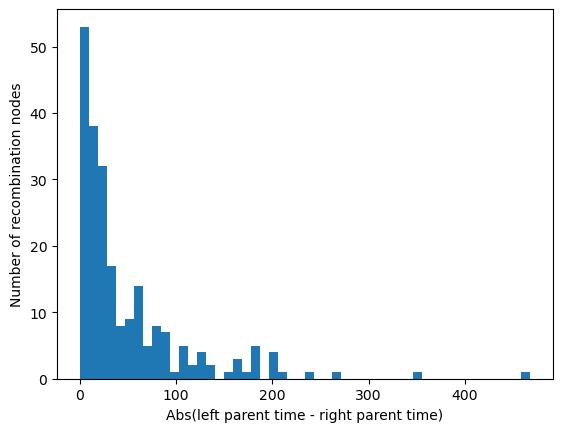

In [12]:
plt.hist(sub_df.parent_time_diff, bins=50)
plt.ylabel("Number of recombination nodes")
plt.xlabel("Abs(left parent time - right parent time)");

In [13]:
def create_heatmap(cofreq, figsize, ylabel, xlabel):
    plt.figure(figsize=figsize)

    fig, ax = plt.subplots()
    im = ax.imshow(cofreq, cmap="viridis", aspect="equal")

    fig.colorbar(im, ax=ax, label="Co-frequency")

    for (i, j), value in np.ndenumerate(cofreq):
        ax.text(
            j, i, f"{value:.2g}",
            ha="center",
            va="center",
            color="white" if im.norm(value) < 0.5 else "black",
        )

    ax.set_xticks(
        np.arange(cofreq.shape[1]),
        labels=getattr(cofreq, "columns", np.arange(cofreq.shape[1])),
    )
    ax.set_yticks(
        np.arange(cofreq.shape[0]),
        labels=getattr(cofreq, "index", np.arange(cofreq.shape[0])),
    )

    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

<Figure size 800x600 with 0 Axes>

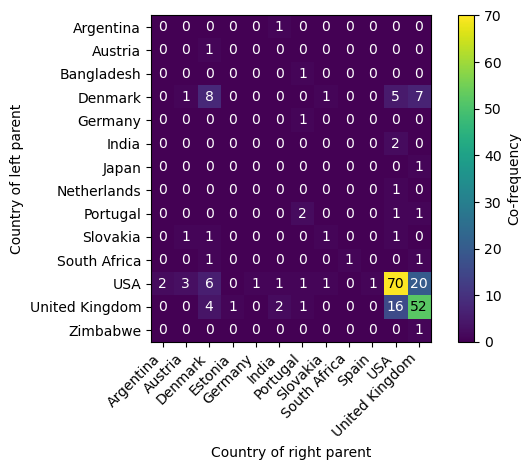

In [14]:
cofreq = pd.crosstab(sub_df["parent_left_country"], sub_df["parent_right_country"])
create_heatmap(cofreq, (8, 6), "Country of left parent", "Country of right parent")

In [15]:
cofreq = pd.crosstab(sub_df["parent_left_region"], sub_df["parent_right_region"])
cofreq

parent_right_region,"Ahmedabad, Gujarat","Anand, Gujarat",Arizona,Arkansas,California,Colorado,Florida,Gauteng,Georgia,Illinois,...,South Carolina,South Dakota,Tennessee,Texas,UK,Utah,Virginia,Washington,Wisconsin,none
parent_left_region,,,,,,,,,,,,,,,,,,,,,
"Ahmedabad, Gujarat, Asia",0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
"Arizona, Pima",0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Arkansas,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
California,0,0,0,0,3,0,0,0,0,0,...,0,0,0,0,4,0,1,0,0,1
Colorado,0,1,0,0,1,3,1,0,0,0,...,0,0,0,1,3,0,0,0,0,0
Connecticut,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
Dhaka,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
Florida,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,1
Free State,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
pd.set_option('display.max_columns', 10)
pd.set_option('display.max_rows', 200)
sub_df[
    [
        "sample_id",
        "num_descendant_samples",
        #"parent_left_time",
        #"parent_right_time",
        "parent_time_diff",
        "parent_left",
        "parent_right",
        #"parent_left_accession",
        #"parent_right_accession",
        "parent_left_country",
        "parent_right_country",
        "parent_left_region",
        "parent_right_region",
    ]
].sort_values("parent_time_diff", ascending=False)

,sample_id,num_descendant_samples,parent_time_diff,parent_left,parent_right,parent_left_country,parent_right_country,parent_left_region,parent_right_region
43,SRR25709216,1,468.0,1422000,1826910,Denmark,USA,none,Colorado
206,SRR23730458,1,351.0,1761375,1288932,South Africa,Denmark,Western Cape,none
223,SRR25053154,1,269.0,1812967,1585461,USA,United Kingdom,Puerto Rico,UK
93,SRR14386539,1,240.0,7422,72950,United Kingdom,USA,UK,California
9,SRR23696120,2,212.0,1532507,1749205,United Kingdom,USA,UK,Colorado
...,...,...,...,...,...,...,...,...,...
159,SRR19279475,1,1.0,743819,748753,USA,USA,Arkansas,Ohio
158,ERR8226498,1,1.0,1028115,1031697,Zimbabwe,United Kingdom,Harare,UK
79,ERR12972009,1,0.0,1529009,1527941,Denmark,Slovakia,none,none
128,SRR27471107,1,0.0,1867922,1867014,USA,USA,Kentucky,Massachusetts


In [ ]:
@numba.njit
def get_descendants(
    focal_node_id: int,
    max_time_increment: float,  # days
    nodes_time: np.ndarray,
    edges_parent: np.ndarray,
    edges_child: np.ndarray,
) -> np.ndarray:
    focal_node_time = nodes_time[focal_node_id]
    min_age = focal_node_time - max_time_increment
    visited = []
    stack = [focal_node_id]
    while len(stack) > 0:
        u = stack.pop(0)
        if nodes_time[u] < min_age:
            continue
        visited.append(u)
        for v in edges_child[edges_parent == u]:
            stack.append(v)
    return np.asarray(visited, dtype=np.int32)

In [18]:
def get_geo_composition(
    focal_node_id: int,
    max_time_increment: float,
    ts: tskit.TreeSequence,
    df: pd.DataFrame,
) -> list:
    countries = []
    desc_nodes = get_descendants(
        focal_node_id,
        max_time_increment=max_time_increment,
        nodes_time=ts.nodes_time,
        edges_child=ts.edges_child,
        edges_parent=ts.edges_parent,
    )
    for u in desc_nodes:
        if ts.nodes_flags[u] != tskit.NODE_IS_SAMPLE:
            continue
        node = ts.node(id_=u)
        sample_id = node.metadata["sample_id"]
        sample_country = df[df["Run"] == sample_id]["Country"].str[:].iloc[0]
        countries.append(sample_country)
    return countries

In [19]:
from collections import Counter
from tqdm import tqdm


MAX_TIME_INC = 28

geo_comps = []
for i, row in tqdm(df.iterrows(), total=len(df)):
    comp_left = Counter(
        get_geo_composition(
            focal_node_id=row.parent_left,
            max_time_increment=MAX_TIME_INC,
            ts=ts,
            df=vir_df,
        )
    )
    comp_right = Counter(
        get_geo_composition(
            focal_node_id=row.parent_right,
            max_time_increment=MAX_TIME_INC,
            ts=ts,
            df=vir_df,
        )
    )
    geo_comps.append(
        {
            "recombinant": row.recombinant,
            "parent_left_is_sample": row.parent_left_is_sample,
            "parent_right_is_sample": row.parent_right_is_sample,
            "parent_left_geo_comp": str(dict(comp_left)),
            "parent_right_geo_comp": str(dict(comp_right)),
        }
    )
geo_comps_df = pd.DataFrame(geo_comps)

100%|██████████| 647/647 [24:09<00:00,  2.24s/it]  


In [21]:
pd.set_option("display.max_rows", 500)
geo_comps_df[
    np.logical_and(
        geo_comps_df.parent_left_is_sample,
        geo_comps_df.parent_right_is_sample,
    )
].reset_index(drop=True)

,recombinant,parent_left_is_sample,parent_right_is_sample,parent_left_geo_comp,parent_right_geo_comp
0,857687,True,True,{'United Kingdom': 3},{'United Kingdom': 10}
1,978075,True,True,{'USA': 25},{'USA': 62}
2,1280575,True,True,{'United Kingdom': 5},{'United Kingdom': 7}
3,1352577,True,True,{'USA': 1},{'United Kingdom': 2}
4,1169203,True,True,{'United Kingdom': 5},{'United Kingdom': 13}
5,1578059,True,True,{'South Africa': 1},{'United Kingdom': 1}
6,1312996,True,True,{'Denmark': 3},{'Denmark': 7}
7,1317828,True,True,"{'Denmark': 2, 'United Kingdom': 1}",{'Denmark': 3}
8,562578,True,True,{'USA': 2},{'USA': 3}
9,1764888,True,True,{'United Kingdom': 1},"{'USA': 13, 'United Kingdom': 3}"


In [24]:
pd.set_option("display.max_rows", 500)
geo_comps_df[
    np.logical_and(
        geo_comps_df.parent_left_is_sample,
        ~geo_comps_df.parent_right_is_sample,
    )
].reset_index(drop=True)

,recombinant,parent_left_is_sample,parent_right_is_sample,parent_left_geo_comp,parent_right_geo_comp
0,1872434,True,False,{'USA': 1},{}
1,1890014,True,False,{'USA': 1},"{'USA': 3, 'Germany': 1}"
2,1793239,True,False,{'United Kingdom': 2},"{'USA': 1, 'United Kingdom': 1}"
3,1818894,True,False,{'USA': 1},{'Netherlands': 2}
4,1314409,True,False,{'United Kingdom': 4},{}
5,1871605,True,False,{'USA': 1},{}
6,140807,True,False,{'United Kingdom': 3},{}
7,425792,True,False,{'USA': 1},{'USA': 2}
8,1218637,True,False,{'United Kingdom': 1},{}
9,528500,True,False,{'Argentina': 1},{'Slovakia': 2}


In [25]:
pd.set_option("display.max_rows", 500)
geo_comps_df[
    np.logical_and(
        ~geo_comps_df.parent_left_is_sample,
        geo_comps_df.parent_right_is_sample,
    )
].reset_index(drop=True)

,recombinant,parent_left_is_sample,parent_right_is_sample,parent_left_geo_comp,parent_right_geo_comp
0,1375030,False,True,{},"{'United Kingdom': 2, 'Slovakia': 3, 'Denmark'..."
1,371402,False,True,{'USA': 5},{'USA': 27}
2,1412237,False,True,{},{'Denmark': 1}
3,1358902,False,True,{'United Kingdom': 2},{'United Kingdom': 3}
4,624513,False,True,{'United Kingdom': 2},{'United Kingdom': 5}
5,1006374,False,True,{'USA': 2},{'USA': 1}
6,1242085,False,True,{},{'USA': 3}
7,492136,False,True,{},"{'Sri Lanka': 16, 'Norway': 1, 'United Kingdom..."
8,90053,False,True,{},{'United Kingdom': 2}
9,1685198,False,True,{},{'USA': 2}


In [26]:
pd.set_option("display.max_rows", 500)
geo_comps_df[
    np.logical_and(
        ~geo_comps_df.parent_left_is_sample,
        ~geo_comps_df.parent_right_is_sample,
    )
].reset_index(drop=True)

,recombinant,parent_left_is_sample,parent_right_is_sample,parent_left_geo_comp,parent_right_geo_comp
0,1358369,False,False,{},{}
1,470812,False,False,{},{}
2,1702293,False,False,{'USA': 2},"{'Thailand': 1, 'United Kingdom': 1, 'Angola': 1}"
3,1251095,False,False,{'United Kingdom': 1},{}
4,1032970,False,False,{},{}
5,1355989,False,False,{},{'United Kingdom': 3}
6,1878898,False,False,{'USA': 1},{'USA': 1}
7,1639830,False,False,{},{}
8,1247289,False,False,{},{'USA': 1}
9,412626,False,False,{},{}


In [43]:
import ast


def parse_geo_comp(comp: dict[str, int]):
    if comp == {}:
        return None
    # When tied, take the alphabetically first country.
    return min(comp, key=lambda k: (-comp[k], k))


parsed_parent_left = []
parsed_parent_right = []

for _, row in geo_comps_df.iterrows():
    print(row.recombinant)
    if row.parent_left_is_sample:
        left_node_id = df.loc[df.recombinant == row.recombinant, "parent_left"].iloc[0]
        left_node = ts.node(id_=left_node_id)
        left_sample_id = left_node.metadata["sample_id"]
        left_country = vir_df.loc[vir_df["Run"] == left_sample_id, "Country"].iloc[0]
        if left_country == "United Kingdom":
            left_country = "UK"
    else:
        left_country = parse_geo_comp(ast.literal_eval(row.parent_left_geo_comp))
    parsed_parent_left.append(left_country)

    if row.parent_right_is_sample:
        right_node_id = df.loc[df.recombinant == row.recombinant, "parent_right"].iloc[0]
        right_node = ts.node(id_=right_node_id)
        right_sample_id = left_node.metadata["sample_id"]
        right_country = vir_df.loc[vir_df["Run"] == left_sample_id, "Country"].iloc[0]
        if right_country == "United Kingdom":
            right_country = "UK"
    else:
        right_country = parse_geo_comp(ast.literal_eval(row.parent_right_geo_comp))
    parsed_parent_right.append(right_country)

assert len(parsed_parent_left) == len(parsed_parent_right)

1872434
1358369
1890014
1793239
857687
470812
978075
1280575
1352577
1169203
1578059
1375030
1818894
1702293
371402
1412237
1251095
1032970
1312996
1317828
1355989
1358902
562578
1878898
1639830
1314409
624513
1764888
1006374
1247289
1871605
140807
425792
1242085
1105581
915945
492136
412626
612180
1132034
1308780
1431253
1876644
90053
1621645
1706095
1685198
373965
445255
1871976
739917
716613
758027
1706445
1456159
1657704
1350909
1295012
1218637
1048697
41914
1855485
547488
455856
560455
571190
528500
1629300
1748208
1616563
1251239
1391384
1162778
1093814
31804
1565729
514006
1827030
1856285
1511159
1705711
1782627
1783943
1485232
1415652
1427466
1752088
1593848
1032506
968340
447115
422661
1701501
1247224
1301067
1462198
1701632
179122
1396639
1169967
673127
1542386
1709677
739656
114056
655653
475290
566375
1444447
1379624
1446971
1073548
1237768
277190
411566
562448
49914
617504
660847
1416322
851713
1833118
1883456
1588680
1863701
1685059
1675705
1837055
1829885
1829094
1560770

In [46]:
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)
cofreq = pd.crosstab(parsed_parent_left, parsed_parent_right)
cofreq

col_0,Angola,Argentina,Austria,Bangladesh,Denmark,Estonia,Germany,India,Japan,Latvia,Netherlands,Portugal,Slovakia,South Africa,Thailand,UK,USA,United Kingdom,Zimbabwe
row_0,,,,,,,,,,,,,,,,,,,
Argentina,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
Austria,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Bangladesh,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Denmark,0,0,0,0,26,0,0,0,0,0,0,0,0,0,0,3,5,2,0
Estonia,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
Germany,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
India,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,1,0,0
Japan,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
Netherlands,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


<Figure size 800x600 with 0 Axes>

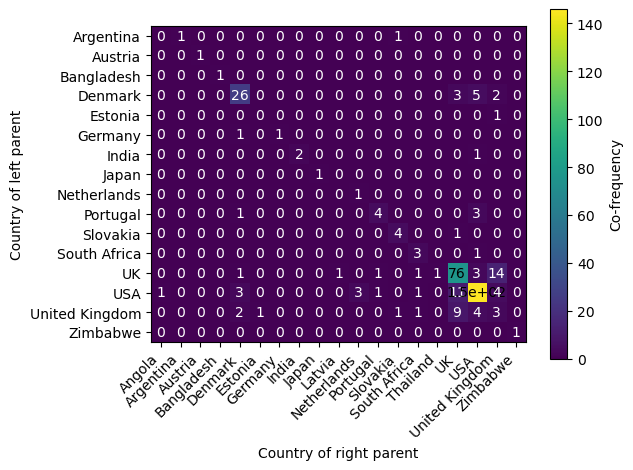

In [47]:
create_heatmap(cofreq, (8, 6), "Country of left parent", "Country of right parent")

In [54]:
sum([x != None and y != None for x, y in zip(parsed_parent_left, parsed_parent_right)])

355